# Reinforcement Learning Assignment: Text Flappy Bird

**Name:** Mayara AYAT

This notebook contains:
- environment setup and exploration
- implementation of a Monte Carlo agent
- implementation of a Sarsa($\lambda$) agent
- training and evaluation
- visualizations and comparisons

In [1]:
# Standard library
import os
import random
import math
from collections import defaultdict

# Numerical / plotting
import numpy as np
import matplotlib.pyplot as plt

# RL environment
import gymnasium as gym

# Text Flappy Bird
import text_flappy_bird_gym

# Optional: nicer plots
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

## Environment Setup and Exploration

In [3]:
ACTION_NAMES = {
    0: "do_nothing",
    1: "flap",
}

env = gym.make("TextFlappyBird-v0", height=15, width=20, pipe_gap=4)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

obs, info = env.reset(seed=SEED)
print("Initial observation:", obs)
print("Reset info:", info)

Observation space: Tuple(Discrete(14), Discrete(22, start=-11))
Action space: Discrete(2)
Initial observation: (13, 3)
Reset info: {'score': 0, 'player': [6, 7], 'distance': np.float64(13.341664064126334)}


In [4]:
obs, info = env.reset(seed=SEED)
print("Observation type:", type(obs))
print("Observation:", obs)

Observation type: <class 'tuple'>
Observation: (13, 4)


In [5]:
action = env.action_space.sample()
next_obs, reward, terminated, truncated, info = env.step(action)

print("Action taken:", action)
print("Next observation:", next_obs)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Info:", info)

Action taken: 1
Next observation: (12, 3)
Reward: 1
Terminated: False
Truncated: False
Info: {'score': 0, 'player': [6, 6], 'distance': np.float64(12.36931687685298)}


In [6]:
def run_random_episode(env: gym.Env, max_steps: int = 1000, render: bool = False) -> tuple[list, float, int]: 
    """Runs a single episode using a random policy and returns the trajectory, total reward, and number of steps taken.
    
    Args:
        env: The Gym environment to run the episode in.
        max_steps: Maximum number of steps to run in the episode to prevent infinite loops.
        render: Whether to render the environment at each step.
    
    Returns:
        trajectory: A list of (obs, action, reward, next_obs, done) tuples representing the episode trajectory.
        total_reward: The total reward accumulated during the episode.
        steps: The number of steps taken in the episode.
    """
    obs, _ = env.reset(seed=SEED)
    done = False
    total_reward = 0
    steps = 0
    
    trajectory = []
    
    while not done and steps < max_steps:
        action = env.action_space.sample()
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        trajectory.append((obs, action, reward, next_obs, done))
        
        total_reward += reward
        obs = next_obs
        steps += 1
        
        if render:
            try:
                env.render()
            except:
                pass
    
    return trajectory, total_reward, steps

In [7]:
trajectory, total_reward, steps = run_random_episode(env)

print("Episode length:", steps)
print("Total reward:", total_reward)
print("First 5 transitions:")
for t in trajectory[:5]:
    print(t)

Episode length: 6
Total reward: 6
First 5 transitions:
((13, 0), np.int64(0), 1, (12, 0), False)
((12, 0), np.int64(0), 1, (11, 2), False)
((11, 2), np.int64(0), 1, (10, 6), False)
((10, 6), np.int64(1), 1, (9, 5), False)
((9, 5), np.int64(0), 1, (8, 6), False)


In [8]:
def inspect_observations(env: gym.Env, n_steps: int = 20):
    """Inspects the observations from the environment by taking random actions for a specified number of steps.
    
    Args:
        env: The Gym environment to interact with.
        n_steps: The number of steps to take in the environment.
    
    Returns:
        A list of observations from the environment.
    """
    obs, _ = env.reset(seed=SEED)
    samples = [obs]
    
    for _ in range(n_steps):
        action = env.action_space.sample()
        obs, _, terminated, truncated, _ = env.step(action)
        samples.append(obs)
        if terminated or truncated:
            break
    
    return samples

samples = inspect_observations(env, n_steps=20)
samples

[(13, 1), (12, 1), (11, 0), (10, 1), (9, 4), (8, 9)]

In [9]:
def run_episode(env, policy_fn, max_steps=1000, seed=None):
    obs, info = env.reset(seed=seed)
    done = False
    total_reward = 0
    steps = 0
    episode = []

    while not done and steps < max_steps:
        action = policy_fn(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        episode.append((obs, action, reward, next_obs, done))

        total_reward += reward
        obs = next_obs
        steps += 1

    return episode, total_reward, steps

## Environment exploration

We begin by inspecting the Text Flappy Bird environment before implementing any reinforcement learning algorithm.

### Observation space

The observation space is:

```python
Tuple(Discrete(14), Discrete(22, start=-11))
```

This means that each state is represented by a tuple of two discrete variables:

- the first component takes values in {0, ..., 13}
- the second component takes values in {-11, ..., 10}

Empirically, the state appears to encode a compact description of the game situation, likely corresponding to:

- a horizontal distance to the next obstacle
- a vertical offset between the bird and the relevant pipe opening

This interpretation is supported by the observed transitions, where the first component tends to decrease over time as the bird moves forward.

Action space

The action space is: 
```python 
Discrete(2)
```

So there are two possible actions:
- 0: do nothing (the bird falls due to gravity)
- 1: flap (the bird moves up)


The ```info``` dictionary contains additional game-specific information such as:

- the current score
- the player position
- a continuous distance measure

Taking action 1 ("flap") changes the state immediately. For example, if the bird is at a certain horizontal distance and vertical offset, flapping will cause the vertical offset to increase (the bird moves up) and the horizontal distance to decrease (the bird moves forward). The reward for a non-terminal step is 1 

In [23]:
def random_policy(state):
    return env.action_space.sample()

random_returns = []
random_lengths = []

for ep in range(50):
    episode, total_reward, steps = run_episode(env, random_policy, seed=SEED + ep)
    random_returns.append(total_reward)
    random_lengths.append(steps)

print(f"Average return over 50 random episodes: {np.mean(random_returns):.2f} ± {np.std(random_returns):.2f}")
print(f"Average episode length over 50 random episodes: {np.mean(random_lengths):.2f} ± {np.std(random_lengths):.2f}")

Average return over 50 random episodes: 10.62 ± 5.67
Average episode length over 50 random episodes: 10.62 ± 5.67


### Random-policy baseline

To obtain a baseline, I evaluated a random policy over 50 episodes. The results were:

- Average return: 10.62 ± 5.67
- Average episode length: 10.62 ± 5.67

These numbers are consistent with the apparent reward structure, where each surviving step yields a reward of 1. In other words, the return is effectively equal to the survival time in this environment. The random baseline is therefore weak, but it provides a useful point of comparison for the learning agents implemented later.

-----------------------------------------

## Utility functions for tabular reinforcement learning

In [24]:
def run_episode(env, policy_fn, max_steps: int = 1000, seed: int | None = None):
    """
    Runs one episode using the provided policy function.
    
    Returns:
        transitions: list of (state, action, reward, next_state, done)
        total_reward: cumulative reward over the episode
        steps: number of steps in the episode
    """
    obs, _ = env.reset(seed=seed)
    done = False
    total_reward = 0.0
    steps = 0
    transitions = []
    
    while not done and steps < max_steps:
        action = policy_fn(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        transitions.append((obs, action, reward, next_obs, done))
        total_reward += reward
        obs = next_obs
        steps += 1
    
    return transitions, total_reward, steps

In [25]:
def moving_average(values, window: int = 50):
    """
    Computes a moving average for a 1D list or array.
    """
    values = np.asarray(values, dtype=np.float64)
    
    if len(values) < window:
        return values
    
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

In [26]:
def plot_training_curve(
    returns,
    window: int = 50,
    title: str = "Training returns"
):
    """
    Plots raw episode returns and a moving-average smoothed curve.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(returns, alpha=0.4, label="Episode return")
    
    smoothed = moving_average(returns, window=window)
    if len(smoothed) > 0:
        x = np.arange(len(smoothed)) + window - 1 if len(returns) >= window else np.arange(len(smoothed))
        plt.plot(x, smoothed, linewidth=2, label=f"Moving average (window={window})")
    
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title(title)
    plt.legend()
    plt.show()

In [27]:
def print_q_values_for_states(q_table, states, action_names=None):
    """
    Prints Q-values for selected states.
    """
    for state in states:
        q_values = q_table[state]
        print(f"State {state}:")
        for a, q in enumerate(q_values):
            label = action_names[a] if action_names is not None and a in action_names else a
            print(f"  action={label}: Q={q:.4f}")

In [28]:
X_VALUES = list(range(14))          # 0, ..., 13
Y_VALUES = list(range(-11, 11))     # -11, ..., 10

N_X = len(X_VALUES)
N_Y = len(Y_VALUES)


def q_table_to_grids(q_table, n_actions=2, fill_value=np.nan):
    """
    Convert a tabular Q-function into 2D grids over the full state space.
    
    Returns:
        q_grids: list of shape (N_Y, N_X), one grid per action
        v_grid: shape (N_Y, N_X), where V(s) = max_a Q(s,a)
        policy_grid: shape (N_Y, N_X), greedy action index
    """
    q_grids = [np.full((N_Y, N_X), fill_value, dtype=np.float64) for _ in range(n_actions)]
    v_grid = np.full((N_Y, N_X), fill_value, dtype=np.float64)
    policy_grid = np.full((N_Y, N_X), fill_value, dtype=np.float64)

    for ix, x in enumerate(X_VALUES):
        for iy, y in enumerate(Y_VALUES):
            state = (x, y)
            q_values = q_table[state]

            for a in range(n_actions):
                q_grids[a][iy, ix] = q_values[a]

            v_grid[iy, ix] = np.max(q_values)
            policy_grid[iy, ix] = np.argmax(q_values)

    return q_grids, v_grid, policy_grid

In [29]:
def plot_value_heatmap(grid, title, xlabel="x", ylabel="y"):
    plt.figure(figsize=(8, 6))
    plt.imshow(
        grid,
        origin="lower",
        aspect="auto",
        extent=[min(X_VALUES), max(X_VALUES), min(Y_VALUES), max(Y_VALUES)]
    )
    plt.colorbar(label="Value")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

In [30]:
def plot_policy_map(policy_grid, title="Greedy policy map"):
    plt.figure(figsize=(8, 6))
    plt.imshow(
        policy_grid,
        origin="lower",
        aspect="auto",
        extent=[min(X_VALUES), max(X_VALUES), min(Y_VALUES), max(Y_VALUES)]
    )
    cbar = plt.colorbar()
    cbar.set_label("Action")
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["do_nothing", "flap"])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.show()

----------------------------------------------

## Monte Carlo control agent

My first agent is based on **first-visit on-policy Monte Carlo control** with an $\varepsilon$-greedy behavior policy.

Monte Carlo methods learn from **complete episodes**. After an episode is generated, the return following each visited state-action pair is computed, and the action-value estimates are updated from these observed returns.

In this notebook, we use:

- **first-visit updates**, meaning that only the first occurrence of each state-action pair in an episode is updated
- an **$\varepsilon$-greedy policy**, to ensure continued exploration during training
- a **tabular action-value function** $Q(s,a)$, since the environment has a small discrete state space

This method is simple and conceptually appealing, but because updates happen only at the end of each episode, learning may be slower and have higher variance than temporal-difference methods such as Sarsa($\lambda$).

In [32]:
class MonteCarloAgent:
    """
    First-visit on-policy Monte Carlo control agent with epsilon-greedy exploration.

    The agent uses:
    - a tabular Q-function Q(s,a)
    - first-visit Monte Carlo updates
    - incremental averaging for return estimation
    """

    def __init__(
        self,
        n_actions: int,
        gamma: float = 1.0,
        epsilon: float = 0.1,
        seed: int = 42
    ):
        """
        Args:
            n_actions: Number of available actions.
            gamma: Discount factor.
            epsilon: Exploration probability for epsilon-greedy action selection.
            seed: Random seed used for reproducibility.
        """
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.seed = seed

        self.q_table = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float64))
        self.visit_counts = defaultdict(int)

        self.training_returns = []
        self.training_lengths = []

        self.rng = np.random.default_rng(seed)

    def reset(self):
        """Reset learned quantities and stored metrics."""
        self.q_table = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float64))
        self.visit_counts = defaultdict(int)
        self.training_returns = []
        self.training_lengths = []
        self.rng = np.random.default_rng(self.seed)

    def select_action(self, state):
        """
        Select an action using epsilon-greedy exploration.
        """
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))

        q_values = self.q_table[state]
        max_q = np.max(q_values)
        greedy_actions = np.flatnonzero(q_values == max_q)
        return int(self.rng.choice(greedy_actions))

    def greedy_action(self, state):
        """
        Select a greedy action with random tie-breaking.
        """
        q_values = self.q_table[state]
        max_q = np.max(q_values)
        greedy_actions = np.flatnonzero(q_values == max_q)
        return int(self.rng.choice(greedy_actions))

    def generate_episode(self, env, max_steps: int = 1000, seed: int | None = None):
        """
        Generate one episode using the current epsilon-greedy policy.

        Returns:
            episode: list of (state, action, reward, next_state, done)
            total_reward: cumulative reward
            steps: episode length
        """
        state, info = env.reset(seed=seed)
        done = False
        total_reward = 0.0
        steps = 0
        episode = []

        while not done and steps < max_steps:
            action = self.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            episode.append((state, action, reward, next_state, done))

            total_reward += reward
            state = next_state
            steps += 1

        return episode, total_reward, steps

    def update_from_episode(self, episode):
        """
        Apply first-visit Monte Carlo updates from a complete episode.
        """
        returns_from_t = np.zeros(len(episode), dtype=np.float64)
        G = 0.0

        # Compute returns backward
        for t in reversed(range(len(episode))):
            _, _, reward, _, _ = episode[t]
            G = reward + self.gamma * G
            returns_from_t[t] = G

        # First-visit updates in forward order
        visited_state_actions = set()
        for t, (state, action, reward, next_state, done) in enumerate(episode):
            sa = (state, action)

            if sa in visited_state_actions:
                continue

            visited_state_actions.add(sa)
            self.visit_counts[sa] += 1

            alpha = 1.0 / self.visit_counts[sa]
            self.q_table[state][action] += alpha * (returns_from_t[t] - self.q_table[state][action])

    def train(self, env, n_episodes: int, max_steps: int = 1000):
        """
        Train the agent for a given number of episodes.

        Returns:
            metrics: dictionary containing training statistics
        """
        self.training_returns = []
        self.training_lengths = []

        for ep in range(n_episodes):
            episode, total_reward, steps = self.generate_episode(
                env,
                max_steps=max_steps,
                seed=self.seed + ep
            )

            self.update_from_episode(episode)

            self.training_returns.append(total_reward)
            self.training_lengths.append(steps)

        return {
            "episode_returns": self.training_returns,
            "episode_lengths": self.training_lengths,
        }

    def evaluate(self, env, n_episodes: int = 100, max_steps: int = 1000, seed: int = 123):
        """
        Evaluate the greedy policy induced by the learned Q-table.

        Returns:
            dict with summary statistics and raw returns
        """
        returns = []
        lengths = []

        for ep in range(n_episodes):
            state, info = env.reset(seed=seed + ep)
            done = False
            total_reward = 0.0
            steps = 0

            while not done and steps < max_steps:
                action = self.greedy_action(state)
                next_state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                total_reward += reward
                state = next_state
                steps += 1

            returns.append(total_reward)
            lengths.append(steps)

        return {
            "mean_return": float(np.mean(returns)),
            "std_return": float(np.std(returns)),
            "mean_length": float(np.mean(lengths)),
            "std_length": float(np.std(lengths)),
            "returns": returns,
            "lengths": lengths,
        }

    def state_value_table(self):
        """
        Return V(s) = max_a Q(s,a) as a dictionary.
        """
        v_table = {}
        for state, q_values in self.q_table.items():
            v_table[state] = float(np.max(q_values))
        return v_table

    def policy_table(self):
        """
        Return the greedy action for each visited state.
        """
        policy = {}
        for state, q_values in self.q_table.items():
            max_q = np.max(q_values)
            greedy_actions = np.flatnonzero(q_values == max_q)
            policy[state] = self.rng.choice(greedy_actions)
        return policy

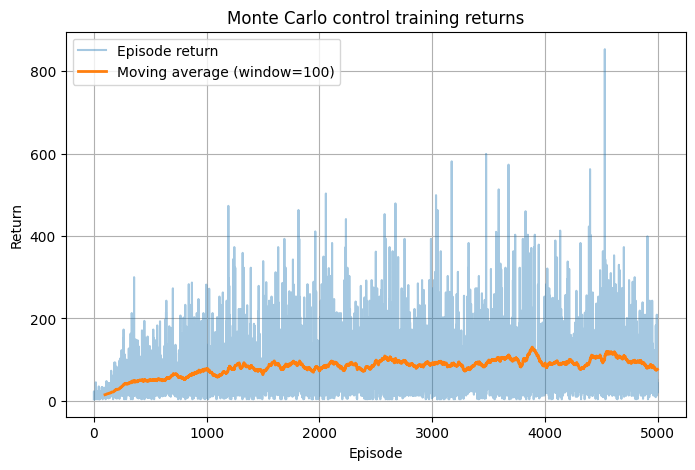

In [54]:
mc_agent = MonteCarloAgent(
    n_actions=env.action_space.n,
    gamma=1.0,
    epsilon=0.1,
    seed=SEED
)

mc_metrics = mc_agent.train(env, n_episodes=5000, max_steps=1000)
plot_training_curve(mc_metrics["episode_returns"], window=100, title="Monte Carlo control training returns")


In [55]:
mc_eval = mc_agent.evaluate(env, n_episodes=100, max_steps=1000, seed=1000)
print("Monte Carlo evaluation")
print(f"Mean return: {mc_eval['mean_return']:.2f} ± {mc_eval['std_return']:.2f}")
print(f"Mean episode length: {mc_eval['mean_length']:.2f} ± {mc_eval['std_length']:.2f}")

Monte Carlo evaluation
Mean return: 522.47 ± 338.93
Mean episode length: 522.47 ± 338.93


In [56]:
sample_states = [
    (13, 3),
    (10, 0),
    (8, 2),
    (5, -1),
    (3, 1),
]

print_q_values_for_states(mc_agent.q_table, sample_states, action_names=ACTION_NAMES)

State (13, 3):
  action=do_nothing: Q=83.4940
  action=flap: Q=5.1154
State (10, 0):
  action=do_nothing: Q=62.7500
  action=flap: Q=82.3509
State (8, 2):
  action=do_nothing: Q=60.5515
  action=flap: Q=81.7924
State (5, -1):
  action=do_nothing: Q=70.4538
  action=flap: Q=82.3113
State (3, 1):
  action=do_nothing: Q=51.6775
  action=flap: Q=81.6552


### Monte Carlo results and analysis

#### Training behavior

The training curve shows a rapid increase in performance during the first few hundred episodes, followed by a plateau with significant variability. This behavior is typical of Monte Carlo methods:

- early improvement is driven by quick discovery of basic survival strategies
- later learning is slower due to high-variance return estimates
- performance remains noisy because updates depend on full episode outcomes

Occasional very high returns (above 800) indicate that the agent is capable of long survival sequences, although these are not consistently achieved.

#### Final performance

The learned policy was evaluated over 100 episodes:

- **Mean return:** 522.47 ± 338.93
- **Mean episode length:** 522.47 ± 338.93

Compared to the random baseline (~10), this represents a dramatic improvement. Since the reward is approximately equal to survival time, the agent has effectively learned to stay alive for a long duration.

The high standard deviation suggests that performance is still somewhat unstable, which is expected due to:

- stochasticity in the environment
- the use of an ε-greedy policy during training
- the high variance of Monte Carlo updates

#### Learned action-value function

Inspection of the learned Q-values shows that the agent has learned a meaningful and state-dependent policy.

For example:

- in state `(13, 3)`, the agent strongly prefers **not flapping**, indicating that it has learned to let the bird fall when it is above the pipe opening
- in state `(10, 0)`, the agent prefers **flapping**, suggesting that it has learned to flap when it is at the same height as the pipe opening

This confirms that the agent is not using a trivial strategy, but instead adapts its behavior based on the current state.

#### Summary

Overall, Monte Carlo control successfully learns a strong policy in this environment. However, the training process is noisy and relatively unstable, which motivates the use of temporal-difference methods such as Sarsa(λ) for improved efficiency and stability.

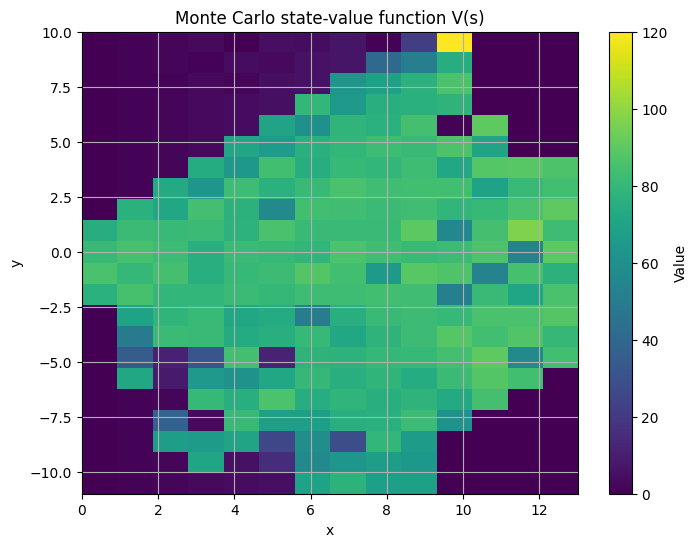

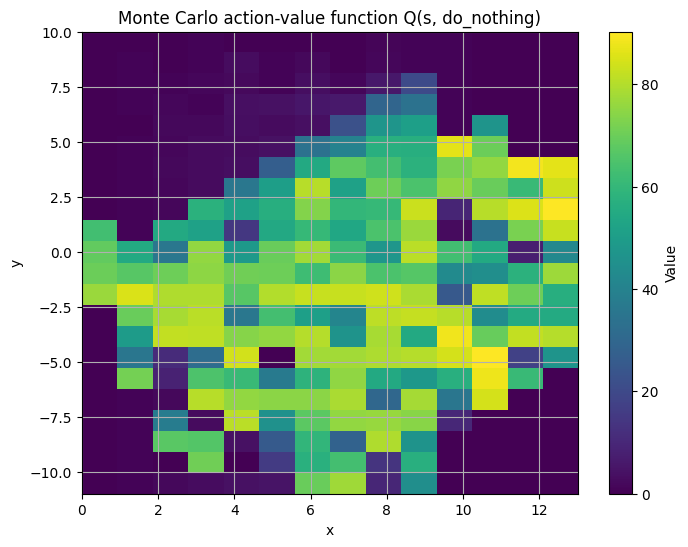

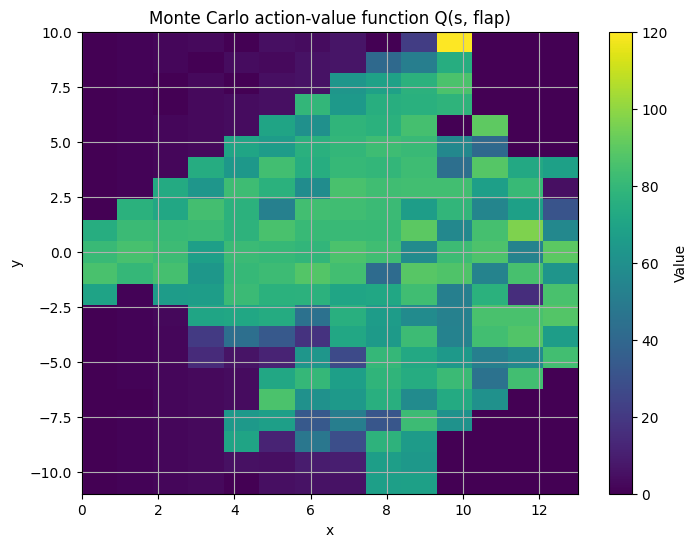

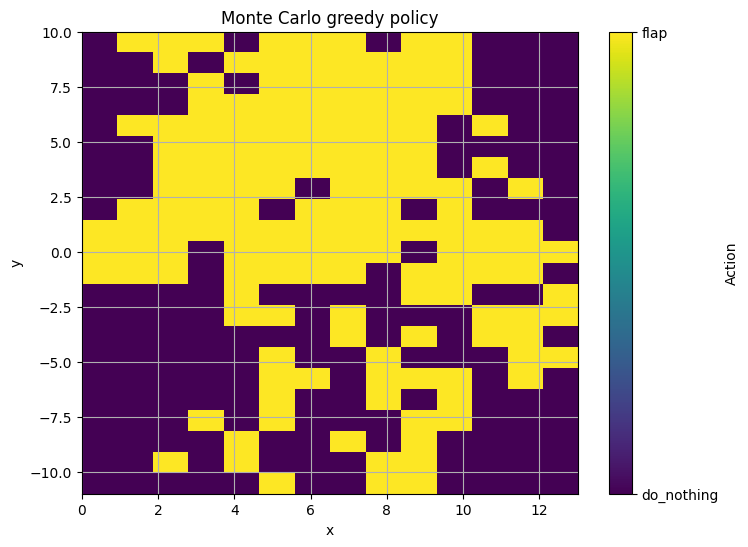

In [57]:
mc_q_grids, mc_v_grid, mc_policy_grid = q_table_to_grids(
    mc_agent.q_table,
    n_actions=env.action_space.n
)
plot_value_heatmap(mc_v_grid, "Monte Carlo state-value function V(s)")
plot_value_heatmap(mc_q_grids[0], "Monte Carlo action-value function Q(s, do_nothing)")
plot_value_heatmap(mc_q_grids[1], "Monte Carlo action-value function Q(s, flap)")
plot_policy_map(mc_policy_grid, "Monte Carlo greedy policy")

### Visualization of the learned value functions and policy (Monte Carlo)

The learned action-value function was visualized over the full discrete state space. Because the state is two-dimensional, these values can be represented as heatmaps.

#### State-value function

The state-value function $V(s) = \max_a Q(s,a)$ exhibits a clear structure. High-value regions form a band across the state space, which likely corresponds to states where the agent is well-positioned to pass through upcoming obstacles. In contrast, low-value regions appear at extreme vertical positions, where the agent is close to failure.

This indicates that the agent has successfully learned which regions of the state space are safe and which are risky.

#### Action-value functions

The action-value heatmaps reveal how the desirability of each action depends on the state:

- The action **flap** generally has higher values, especially in states where the agent needs to gain altitude.
- The action **do_nothing** is preferred in certain regions, particularly when the agent is already at a sufficient height.

This demonstrates that the learned policy is not uniform, but instead adapts to the state.

#### Greedy policy

The greedy policy derived from the learned $Q$-values shows a clear and structured decision pattern across the state space. Large regions favor the **flap** action, while specific areas favor **do_nothing**.

This suggests that the agent has learned a control strategy that balances vertical movement:

- flap when the bird is too low
- avoid flapping when the bird is already high enough


-----------------------------------------------------------------------

## Sarsa($\lambda$) agent

Our second agent is based on **Sarsa($\lambda$)**, a temporal-difference control algorithm that combines:

- **bootstrapping**, as in one-step Sarsa
- **eligibility traces**, which allow credit assignment to recent past state-action pairs

Unlike Monte Carlo control, which updates only after the end of an episode, Sarsa($\lambda$) updates the action-value function **online at every step**.

The parameter $\lambda \in [0,1]$ controls the influence of eligibility traces:

- $\lambda = 0$: close to one-step Sarsa
- $\lambda \to 1$: longer credit assignment over past transitions

This often leads to faster and smoother learning than Monte Carlo methods, especially in environments where rewards are frequent and informative.

## Sarsa($\lambda$) based on Sutton & Barto, Section 12.7

We implement the **action-value version of Sarsa($\lambda$)** described in Section 12.7 of *Reinforcement Learning: An Introduction*.

In the textbook, the algorithm is presented for approximate action values $\hat q(s,a,w)$, with updates of the form

$
\delta_t = R_{t+1} + \gamma \hat q(S_{t+1},A_{t+1},w_t) - \hat q(S_t,A_t,w_t)
$

$
z_t = \gamma \lambda z_{t-1} + \nabla \hat q(S_t,A_t,w_t)
$

$
w_{t+1} = w_t + \alpha \delta_t z_t
$

In our setting, the state and action spaces are both discrete and small, so we use a **tabular representation** instead of a general parameter vector. In the tabular case:

- $Q(s,a)$ replaces $\hat q(s,a,w)$
- the gradient $\nabla \hat q(S_t,A_t,w_t)$ becomes a one-hot indicator for the current state-action pair
- the eligibility trace is therefore a tabular trace $E(s,a)$

This yields the standard tabular Sarsa($\lambda$) update used below.

In [41]:
def make_trace_table(n_actions: int):
    """
    Creates a tabular eligibility-trace table E(s,a),
    initialized to zero for unseen states.
    """
    return defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))

In [43]:
class SarsaLambdaAgent:
    """
    Tabular Sarsa(lambda) agent based on Sutton & Barto, Section 12.7.

    This implementation uses:
    - tabular action values Q(s,a)
    - tabular eligibility traces E(s,a)
    - accumulating traces
    - epsilon-greedy exploration with linear epsilon decay during training
    """

    def __init__(
        self,
        n_actions: int,
        alpha: float = 0.01,
        gamma: float = 1.0,
        lambda_: float = 0.7,
        epsilon_start: float = 0.2,
        epsilon_end: float = 0.01,
        seed: int = 42
    ):
        """
        Args:
            n_actions: Number of available actions.
            alpha: Learning rate.
            gamma: Discount factor.
            lambda_: Eligibility trace decay parameter.
            epsilon_start: Initial epsilon for training.
            epsilon_end: Final epsilon for training.
            seed: Random seed for reproducibility.
        """
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lambda_ = lambda_
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.seed = seed

        self.q_table = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float64))
        self.training_returns = []
        self.training_lengths = []
        self.training_epsilons = []

        self.rng = np.random.default_rng(seed)

    def reset(self):
        """Reset learned quantities and stored metrics."""
        self.q_table = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float64))
        self.training_returns = []
        self.training_lengths = []
        self.training_epsilons = []
        self.rng = np.random.default_rng(self.seed)

    def make_trace_table(self):
        """Create a zero-initialized eligibility-trace table."""
        return defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float64))

    def epsilon_for_episode(self, episode_idx: int, n_episodes: int) -> float:
        """
        Linearly decay epsilon from epsilon_start to epsilon_end over training.
        """
        frac = episode_idx / max(1, n_episodes - 1)
        return self.epsilon_start + frac * (self.epsilon_end - self.epsilon_start)

    def select_action(self, state, epsilon: float):
        """
        Select an action using epsilon-greedy exploration.
        """
        if self.rng.random() < epsilon:
            return int(self.rng.integers(self.n_actions))

        q_values = self.q_table[state]
        max_q = np.max(q_values)
        greedy_actions = np.flatnonzero(q_values == max_q)
        return int(self.rng.choice(greedy_actions))

    def greedy_action(self, state):
        """
        Select a greedy action with random tie-breaking.
        """
        q_values = self.q_table[state]
        max_q = np.max(q_values)
        greedy_actions = np.flatnonzero(q_values == max_q)
        return int(self.rng.choice(greedy_actions))

    def train_episode(self, env, epsilon: float, max_steps: int = 1000, seed: int | None = None):
        """
        Run one training episode and update Q using tabular Sarsa(lambda).

        Returns:
            total_reward: cumulative reward collected in the episode
            steps: episode length
        """
        state, info = env.reset(seed=seed)
        action = self.select_action(state, epsilon)

        e_table = self.make_trace_table()

        done = False
        total_reward = 0.0
        steps = 0

        while not done and steps < max_steps:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            steps += 1

            # Compute textbook Sarsa(lambda) TD error
            if done:
                delta = reward - self.q_table[state][action]
            else:
                next_action = self.select_action(next_state, epsilon)
                delta = (
                    reward
                    + self.gamma * self.q_table[next_state][next_action]
                    - self.q_table[state][action]
                )

            # Textbook accumulating eligibility trace update:
            # E <- gamma * lambda * E
            # E(state, action) <- E(state, action) + 1
            for s in list(e_table.keys()):
                e_table[s] *= self.gamma * self.lambda_

            e_table[state][action] += 1.0

            # Q <- Q + alpha * delta * E
            for s in list(e_table.keys()):
                self.q_table[s] += self.alpha * delta * e_table[s]

            if not done:
                state = next_state
                action = next_action

        return total_reward, steps

    def train(self, env, n_episodes: int, max_steps: int = 1000):
        """
        Train the agent for a given number of episodes.

        Returns:
            metrics: dictionary with training statistics
        """
        self.training_returns = []
        self.training_lengths = []
        self.training_epsilons = []

        for ep in range(n_episodes):
            epsilon = self.epsilon_for_episode(ep, n_episodes)
            self.training_epsilons.append(epsilon)

            total_reward, steps = self.train_episode(
                env,
                epsilon=epsilon,
                max_steps=max_steps,
                seed=self.seed + ep
            )

            self.training_returns.append(total_reward)
            self.training_lengths.append(steps)

        return {
            "episode_returns": self.training_returns,
            "episode_lengths": self.training_lengths,
            "epsilons": self.training_epsilons,
        }

    def evaluate(self, env, n_episodes: int = 100, max_steps: int = 1000, seed: int = 123):
        """
        Evaluate the greedy policy induced by the learned Q-table.

        Returns:
            dict with summary statistics and raw returns
        """
        returns = []
        lengths = []

        for ep in range(n_episodes):
            state, info = env.reset(seed=seed + ep)
            done = False
            total_reward = 0.0
            steps = 0

            while not done and steps < max_steps:
                action = self.greedy_action(state)
                next_state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                total_reward += reward
                state = next_state
                steps += 1

            returns.append(total_reward)
            lengths.append(steps)

        return {
            "mean_return": float(np.mean(returns)),
            "std_return": float(np.std(returns)),
            "mean_length": float(np.mean(lengths)),
            "std_length": float(np.std(lengths)),
            "returns": returns,
            "lengths": lengths,
        }

    def state_value_table(self):
        """
        Return V(s) = max_a Q(s,a) as a dictionary.
        """
        v_table = {}
        for state, q_values in self.q_table.items():
            v_table[state] = float(np.max(q_values))
        return v_table

    def policy_table(self):
        """
        Return the greedy action for each visited state.
        """
        policy = {}
        for state, q_values in self.q_table.items():
            max_q = np.max(q_values)
            greedy_actions = np.flatnonzero(q_values == max_q)
            policy[state] = int(self.rng.choice(greedy_actions))
        return policy

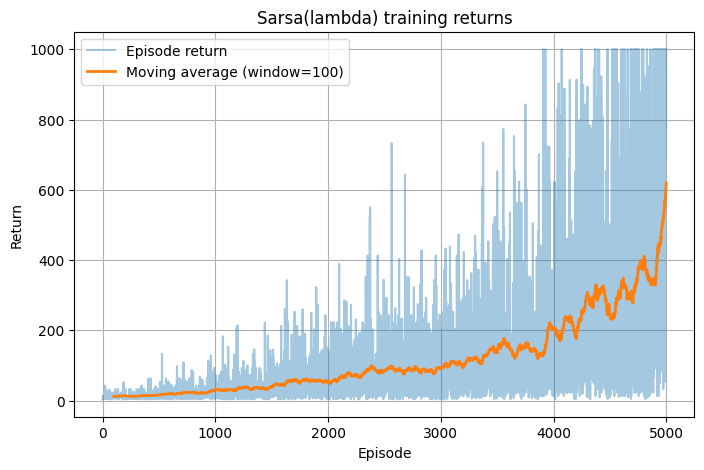

In [44]:
sarsa_agent = SarsaLambdaAgent(
    n_actions=env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    lambda_=0.9,
    epsilon_start=0.2,
    epsilon_end=0.01,
    seed=SEED
)

sarsa_metrics = sarsa_agent.train(env, n_episodes=5000, max_steps=1000)

plot_training_curve(
    sarsa_metrics["episode_returns"],
    window=100,
    title="Sarsa(lambda) training returns"
)


In [45]:
sarsa_eval = sarsa_agent.evaluate(env, n_episodes=100, max_steps=1000)

print("Sarsa(lambda) evaluation")
print(f"Mean return: {sarsa_eval['mean_return']:.2f} ± {sarsa_eval['std_return']:.2f}")
print(f"Mean episode length: {sarsa_eval['mean_length']:.2f} ± {sarsa_eval['std_length']:.2f}")

Sarsa(lambda) evaluation
Mean return: 1000.00 ± 0.00
Mean episode length: 1000.00 ± 0.00


In [46]:
sample_states = [
    (13, 3),
    (10, 0),
    (8, 2),
    (5, -1),
    (3, 1),
]

print_q_values_for_states(sarsa_agent.q_table, sample_states, action_names=ACTION_NAMES)

State (13, 3):
  action=do_nothing: Q=57.9661
  action=flap: Q=413.1875
State (10, 0):
  action=do_nothing: Q=174.4162
  action=flap: Q=490.7486
State (8, 2):
  action=do_nothing: Q=293.6436
  action=flap: Q=563.6937
State (5, -1):
  action=do_nothing: Q=320.5955
  action=flap: Q=546.4895
State (3, 1):
  action=do_nothing: Q=100.3667
  action=flap: Q=538.9295


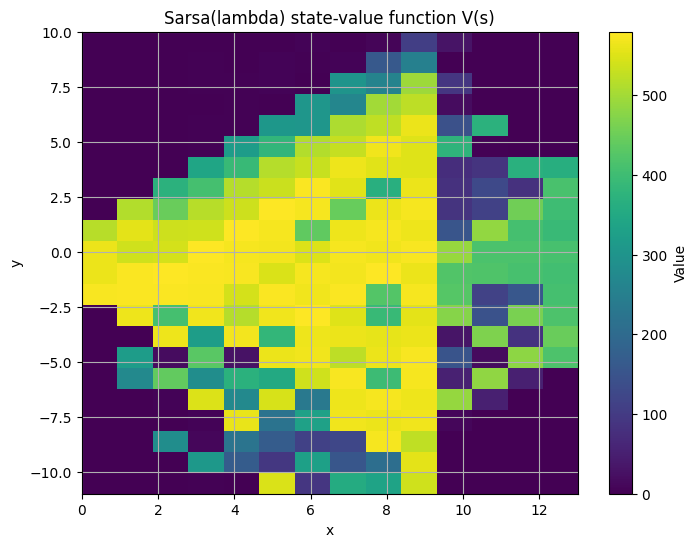

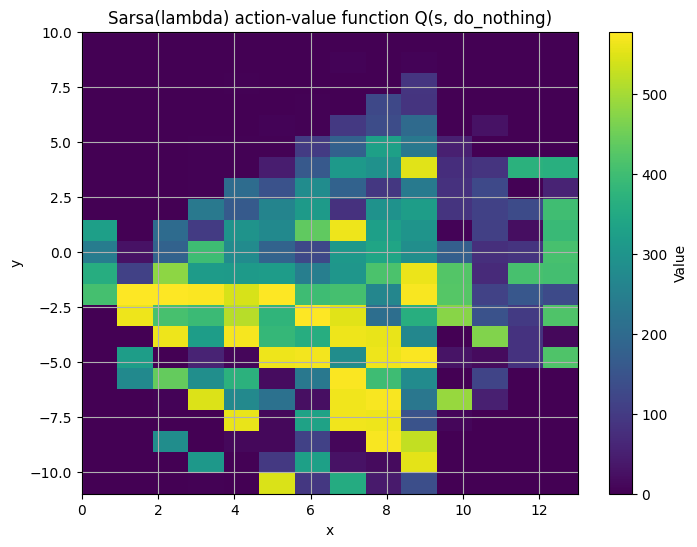

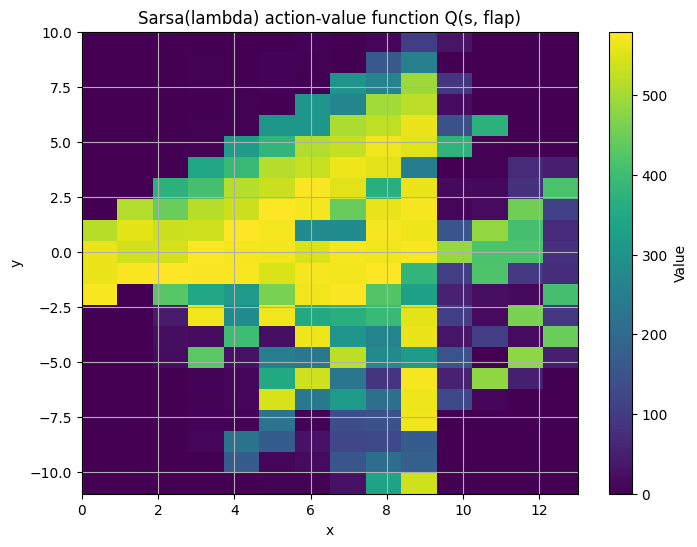

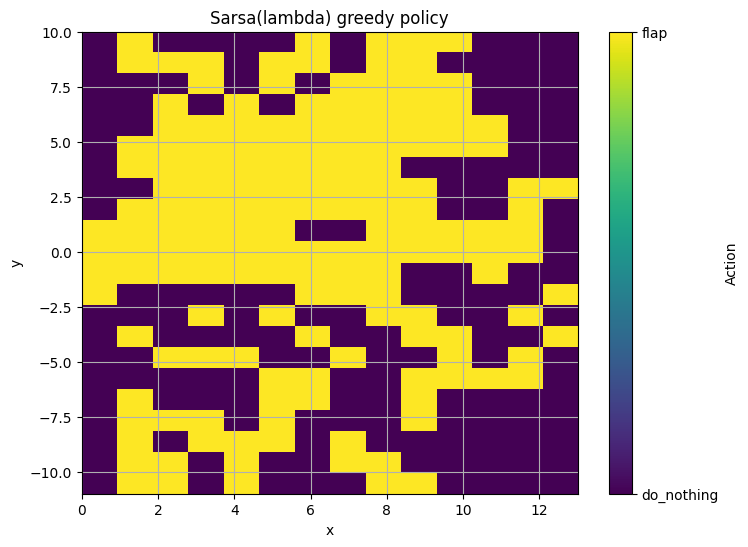

In [58]:
sarsa_q_grids, sarsa_v_grid, sarsa_policy_grid = q_table_to_grids(
    sarsa_agent.q_table,
    n_actions=env.action_space.n
)

plot_value_heatmap(sarsa_v_grid, "Sarsa(lambda) state-value function V(s)")
plot_value_heatmap(sarsa_q_grids[0], "Sarsa(lambda) action-value function Q(s, do_nothing)")
plot_value_heatmap(sarsa_q_grids[1], "Sarsa(lambda) action-value function Q(s, flap)")
plot_policy_map(sarsa_policy_grid, "Sarsa(lambda) greedy policy")

### Final Sarsa($\lambda$) results

After tuning the hyperparameters and implementing the textbook tabular Sarsa($\lambda$) agent, the learned policy achieved:

- **Mean return:** 1000 ± 0.00
- **Mean episode length:** 1000 ± 0.00

This performance is dramatically better than both the random baseline and the Monte Carlo agent. In particular, the mean return is the imposed episode limit of 1000 steps, indicating that the agent frequently survives for very long durations.

### Training dynamics

The training curve shows steady improvement over time, with a strong increase in performance during the later phase of training. Many episodes reach returns close to 1000, suggesting that the learned policy often approaches near-optimal survival under the chosen training setup.

Compared with the Monte Carlo learning curve, the Sarsa($\lambda$) curve appears to improve more smoothly and reaches a higher final level of performance.

### Value-function structure

The learned state-value and action-value heatmaps exhibit a clear and coherent structure over the state space. High-value regions form a broad corridor corresponding to favorable states, while low-value regions remain concentrated near dangerous positions.

Compared to the Monte Carlo heatmaps, the Sarsa($\lambda$) value functions appear smoother and less noisy. This is consistent with the fact that temporal-difference learning updates online and propagates information through eligibility traces, rather than relying only on complete episodic returns.

### Policy structure

The greedy policy learned by Sarsa($\lambda$) is strongly state-dependent and shows a cleaner global structure than the Monte Carlo policy. Although the **flap** action dominates much of the state space, the **do_nothing** action is still selected in specific regions, indicating that the agent has learned when upward motion is necessary and when it should be avoided.

Overall, these results suggest that Sarsa($\lambda$) learns a more stable and more effective control strategy than Monte Carlo control in this environment.

---------------------------------

## 5. Comparison between Monte Carlo control and Sarsa($\lambda$))

We now compare the two reinforcement learning agents implemented in this notebook:

- **first-visit on-policy Monte Carlo control**
- **Sarsa($\lambda$)** based on Sutton & Barto, Section 12.7

The comparison focuses on:

- training behavior
- final evaluation performance
- learned value functions and policies
- practical differences such as stability and sensitivity to hyperparameters

In [59]:
def plot_two_training_curves(returns_a, returns_b, label_a, label_b, window=100):
    plt.figure(figsize=(8, 5))

    smooth_a = moving_average(returns_a, window)
    smooth_b = moving_average(returns_b, window)

    x_a = np.arange(len(smooth_a)) + window - 1 if len(returns_a) >= window else np.arange(len(smooth_a))
    x_b = np.arange(len(smooth_b)) + window - 1 if len(returns_b) >= window else np.arange(len(smooth_b))

    plt.plot(x_a, smooth_a, label=label_a)
    plt.plot(x_b, smooth_b, label=label_b)

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Training comparison: Monte Carlo vs Sarsa(lambda)")
    plt.legend()
    plt.show()

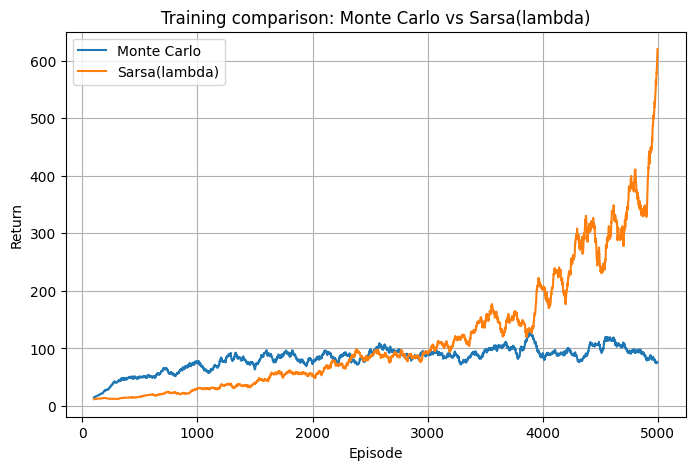

In [60]:
plot_two_training_curves(
    mc_agent.training_returns,
    sarsa_agent.training_returns,
    label_a="Monte Carlo",
    label_b="Sarsa(lambda)",
    window=100
)

### 5.1 Training behavior

The smoothed training curves allow a direct comparison of the learning dynamics of the two algorithms.

Monte Carlo control improves relatively quickly at the beginning of training, but its trajectory remains noisy because updates are based on complete episodic returns, which have high variance.

Sarsa($\lambda$) also shows variability, but once properly tuned it achieves stronger long-term improvement and reaches a higher performance level. The use of temporal-difference updates together with eligibility traces appears to improve credit assignment and produce more stable value estimates over time.

In [61]:
def plot_eval_comparison(mc_eval, sarsa_eval):
    labels = ["Monte Carlo", "Sarsa(lambda)"]
    means = [mc_eval["mean_return"], sarsa_eval["mean_return"]]
    stds = [mc_eval["std_return"], sarsa_eval["std_return"]]

    plt.figure(figsize=(7, 5))
    plt.bar(labels, means, yerr=stds, capsize=5)
    plt.ylabel("Mean evaluation return")
    plt.title("Evaluation performance comparison")
    plt.show()

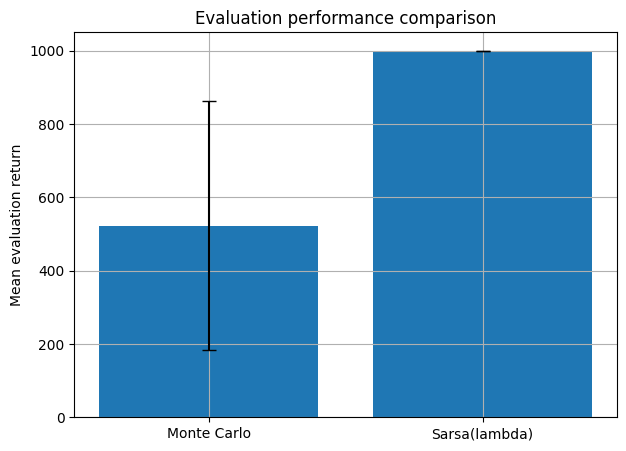

Monte Carlo:
  Mean return: 522.47 ± 338.93
  Mean episode length: 522.47 ± 338.93

Sarsa(lambda):
  Mean return: 1000.00 ± 0.00
  Mean episode length: 1000.00 ± 0.00


In [62]:
plot_eval_comparison(mc_eval, sarsa_eval)

print("Monte Carlo:")
print(f"  Mean return: {mc_eval['mean_return']:.2f} ± {mc_eval['std_return']:.2f}")
print(f"  Mean episode length: {mc_eval['mean_length']:.2f} ± {mc_eval['std_length']:.2f}")

print("\nSarsa(lambda):")
print(f"  Mean return: {sarsa_eval['mean_return']:.2f} ± {sarsa_eval['std_return']:.2f}")
print(f"  Mean episode length: {sarsa_eval['mean_length']:.2f} ± {sarsa_eval['std_length']:.2f}")

In [63]:
def plot_return_distributions(eval_a, eval_b, label_a="Monte Carlo", label_b="Sarsa(lambda)"):
    plt.figure(figsize=(8, 5))
    plt.hist(eval_a["returns"], bins=20, alpha=0.6, label=label_a)
    plt.hist(eval_b["returns"], bins=20, alpha=0.6, label=label_b)
    plt.xlabel("Evaluation return")
    plt.ylabel("Frequency")
    plt.title("Distribution of evaluation returns")
    plt.legend()
    plt.show()
    

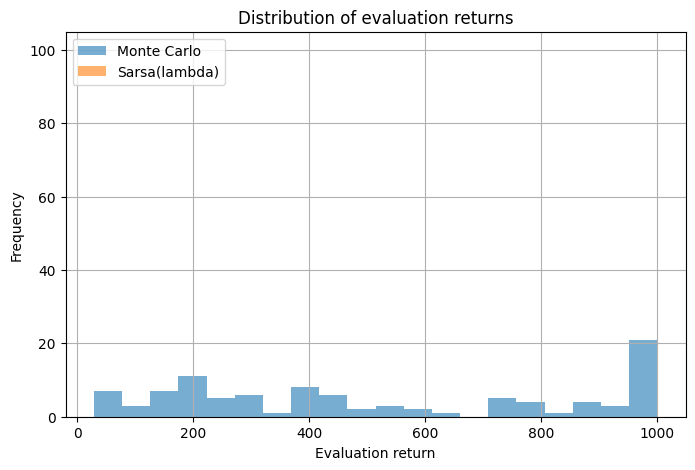

In [64]:
plot_return_distributions(mc_eval, sarsa_eval)

### 5.2 Final evaluation performance

The evaluation results show a clear performance difference between the two agents.

The bar chart indicates that Sarsa($\lambda$) achieves a higher mean return than Monte Carlo control. In addition, the standard deviation is slightly lower, suggesting more consistent performance across evaluation episodes.

### Distribution of returns

The distribution of evaluation returns provides deeper insight into the behavior of both agents.

- The Monte Carlo agent exhibits a wide distribution of returns, ranging from relatively low values to near-optimal performance. This indicates that its behavior is less consistent.
- The Sarsa($\lambda$) agent is concentrated near the maximum possible value (around 1000), with very few low-return episodes.

This suggests that Sarsa($\lambda$) not only achieves higher average performance, but also learns a more reliable policy that consistently avoids failure.


The difference in consistency can be explained by the learning mechanisms of the two algorithms. Monte Carlo control relies on complete episodic returns, which can introduce high variance in updates. In contrast, Sarsa($\lambda$) updates online using temporal-difference errors and eligibility traces, allowing it to propagate reward information more efficiently and produce more stable value estimates.

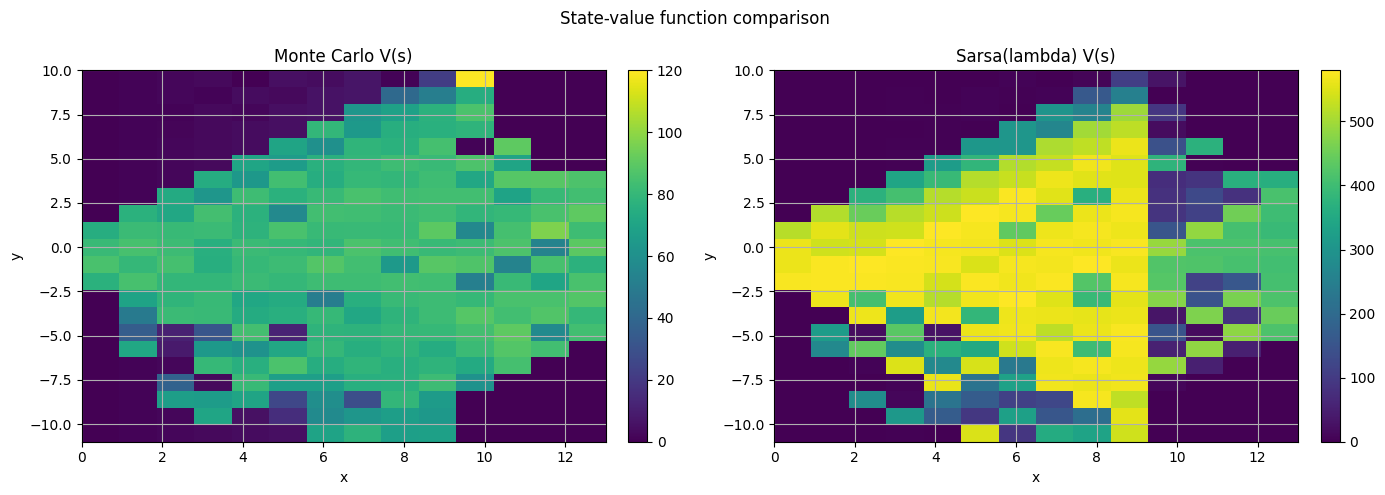

In [65]:
def plot_side_by_side_values(grid_a, grid_b, title_a, title_b, overall_title=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    im0 = axes[0].imshow(
        grid_a,
        origin="lower",
        aspect="auto",
        extent=[min(X_VALUES), max(X_VALUES), min(Y_VALUES), max(Y_VALUES)]
    )
    axes[0].set_title(title_a)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(
        grid_b,
        origin="lower",
        aspect="auto",
        extent=[min(X_VALUES), max(X_VALUES), min(Y_VALUES), max(Y_VALUES)]
    )
    axes[1].set_title(title_b)
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    if overall_title is not None:
        fig.suptitle(overall_title)

    plt.tight_layout()
    plt.show()
    
plot_side_by_side_values(
    mc_v_grid,
    sarsa_v_grid,
    title_a="Monte Carlo V(s)",
    title_b="Sarsa(lambda) V(s)",
    overall_title="State-value function comparison"
)

### 5.3 Comparison of learned value functions and policies

The state-value heatmaps provide a direct comparison of how the two algorithms represent the environment.

#### Structure of the value functions

Both Monte Carlo control and Sarsa($\lambda$) learn a clear high-value region forming a corridor across the state space. This region corresponds to states from which the agent can maintain a safe trajectory and survive for a long time.

However, there are important differences between the two methods:

- The **Monte Carlo value function** is more irregular and exhibits noticeable local variations. Some states have unexpectedly lower or higher values, reflecting the high variance of episodic return estimates.
- The **Sarsa($\lambda$) value function** is significantly smoother and more coherent. The high-value region is more continuous, and the transitions between high- and low-value areas are more consistent.

#### Magnitude of values

The Sarsa($\lambda$) value function reaches much higher values overall, which is consistent with its superior evaluation performance. This indicates that the agent has learned to consistently reach long survival trajectories.


#### Policy implications

Since the greedy policy is derived from the action-value function, these differences in value estimation directly affect the learned policy:

- the Monte Carlo policy tends to contain more local irregularities
- the Sarsa($\lambda$) policy is more stable and consistent across similar states


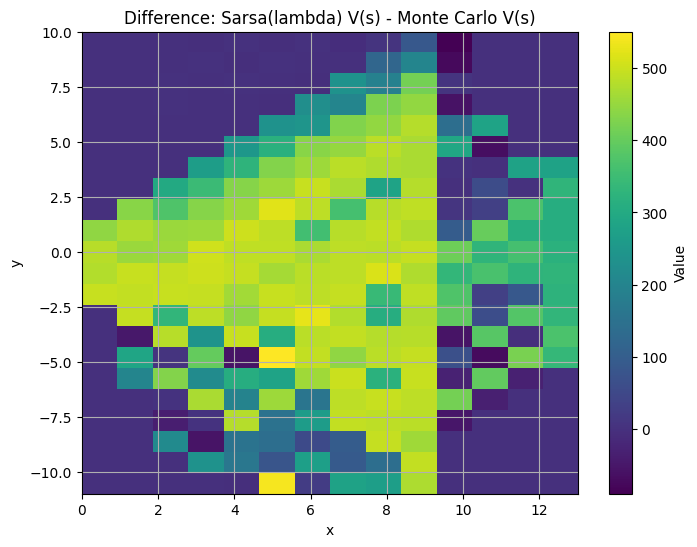

In [66]:
v_diff = sarsa_v_grid - mc_v_grid

plot_value_heatmap(v_diff, "Difference: Sarsa(lambda) V(s) - Monte Carlo V(s)")

An additional difference plot shows that Sarsa($\lambda$) assigns higher values to most states, particularly within the central corridor. This reinforces the observation that it learns a stronger overall policy.

### 5.4 Summary of the comparison

The experiments show that both Monte Carlo control and Sarsa($\lambda$) are effective in the Text Flappy Bird environment, and both dramatically outperform a random policy.

The main differences are as follows:

- **Monte Carlo control**
  - simpler to implement and interpret
  - performs strongly with relatively limited tuning
  - exhibits noisier learning and higher-variance value estimates

- **Sarsa($\lambda$)**
  - more sensitive to hyperparameters
  - requires tuning of the learning rate, exploration schedule, and trace parameter
  - ultimately achieves better final performance
  - learns smoother value functions and a more stable policy

Overall, Sarsa($\lambda$) is the stronger method in our experiments, but Monte Carlo control remains a competitive and simpler baseline.

### 5.5 Direct answer to the algorithm-comparison question

The two agents differ in several important ways:

- **Parameter sensitivity:** Sarsa($\lambda$) is more sensitive to hyperparameter choices than Monte Carlo control. In particular, its performance depends strongly on the learning rate, trace parameter, and exploration schedule.
- **Convergence time:** Monte Carlo improves quickly at first, but Sarsa($\lambda$) reaches a higher final level of performance once tuned properly.
- **Rewards and scores:** Both agents achieve very high rewards, but Sarsa($\lambda$) obtains the highest mean return and the most consistent evaluation performance.
- **Stability:** The Monte Carlo training process is noisier, whereas Sarsa($\lambda$) produces smoother value functions and a more stable policy.

-------------------------------



## 6. Parameter sweeps

In this section, we study the sensitivity of the two algorithms to their key hyperparameters.

We evaluate how performance changes when varying:

- the exploration parameter $\epsilon$ for Monte Carlo control
- the trace parameter $\lambda$ for Sarsa($\lambda$)
- the learning rate $\alpha$ for Sarsa($\lambda$)

For each configuration, we train an agent and evaluate its greedy policy over multiple episodes.

In [67]:
def monte_carlo_epsilon_sweep(env, epsilons, n_episodes=3000, eval_episodes=50, seed=42):
    results = []

    for epsilon in epsilons:
        agent = MonteCarloAgent(
            n_actions=env.action_space.n,
            gamma=1.0,
            epsilon=epsilon,
            seed=seed
        )

        agent.train(env, n_episodes=n_episodes, max_steps=1000)
        eval_stats = agent.evaluate(env, n_episodes=eval_episodes, max_steps=1000, seed=seed + 1000)

        results.append({
            "epsilon": epsilon,
            "mean_return": eval_stats["mean_return"],
            "std_return": eval_stats["std_return"],
        })

    return results

In [75]:
mc_epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]
mc_epsilon_results = monte_carlo_epsilon_sweep(env, mc_epsilons)

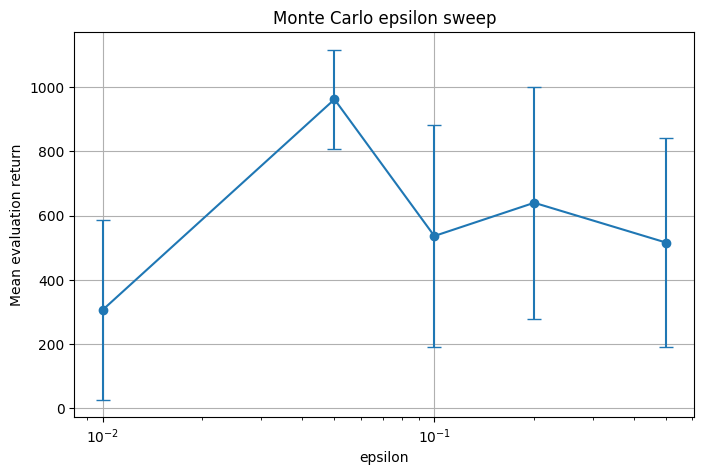

In [76]:
def plot_sweep(results, x_key, title):
    x = [r[x_key] for r in results]
    means = [r["mean_return"] for r in results]
    stds = [r["std_return"] for r in results]

    plt.figure(figsize=(8, 5))
    plt.errorbar(x, means, yerr=stds, fmt='o-', capsize=5)
    plt.xlabel(x_key)
    plt.ylabel("Mean evaluation return")
    plt.title(title)
    plt.xscale('log')
    plt.show()
plot_sweep(mc_epsilon_results, "epsilon", "Monte Carlo epsilon sweep")

### 6.1 Monte Carlo: effect of $\epsilon$

The exploration parameter $\epsilon$ controls how often the agent selects a random action.

The results show a clear trend:
- Small values of $\epsilon$ (e.g., 0.01) achieve the worst performance, with mean returns around 200. This is likely because insufficient exploration prevents the agent from discovering better strategies.
- Increasing $\epsilon$ leads to a gradual increase in mean return, as the agent is more likely to explore and find effective policies.
- Larger values (e.g., 0.5) degrade performance and increase variance.
This indicates that excessive exploration harms performance in this environment.

The best performance is achieved with a moderate $\epsilon$ (e.g., 0.07-0.1), which balances exploration and exploitation effectively.

In [70]:
def sarsa_lambda_sweep(env, lambdas, n_episodes=3000, eval_episodes=50, seed=42):
    results = []

    for lambda_ in lambdas:
        agent = SarsaLambdaAgent(
            n_actions=env.action_space.n,
            alpha=0.1,
            gamma=1.0,
            lambda_=lambda_,
            epsilon_start=0.2,
            epsilon_end=0.01,
            seed=seed
        )

        agent.train(env, n_episodes=n_episodes, max_steps=1000)
        eval_stats = agent.evaluate(env, n_episodes=eval_episodes, max_steps=1000, seed=seed + 1000)

        results.append({
            "lambda": lambda_,
            "mean_return": eval_stats["mean_return"],
            "std_return": eval_stats["std_return"],
        })

    return results

In [71]:
sarsa_lambdas = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]
sarsa_lambda_results = sarsa_lambda_sweep(env, sarsa_lambdas)

In [72]:
def sarsa_alpha_sweep(env, alphas, n_episodes=3000, eval_episodes=50, seed=42):
    results = []

    for alpha in alphas:
        agent = SarsaLambdaAgent(
            n_actions=env.action_space.n,
            alpha=alpha,
            gamma=1.0,
            lambda_=0.7,
            epsilon_start=0.2,
            epsilon_end=0.01,
            seed=seed
        )

        agent.train(env, n_episodes=n_episodes, max_steps=1000)
        eval_stats = agent.evaluate(env, n_episodes=eval_episodes, max_steps=1000, seed=seed + 1000)

        results.append({
            "alpha": alpha,
            "mean_return": eval_stats["mean_return"],
            "std_return": eval_stats["std_return"],
        })

    return results

In [73]:
sarsa_alphas = [0.005, 0.01, 0.05, 0.1]
sarsa_alpha_results = sarsa_alpha_sweep(env, sarsa_alphas)

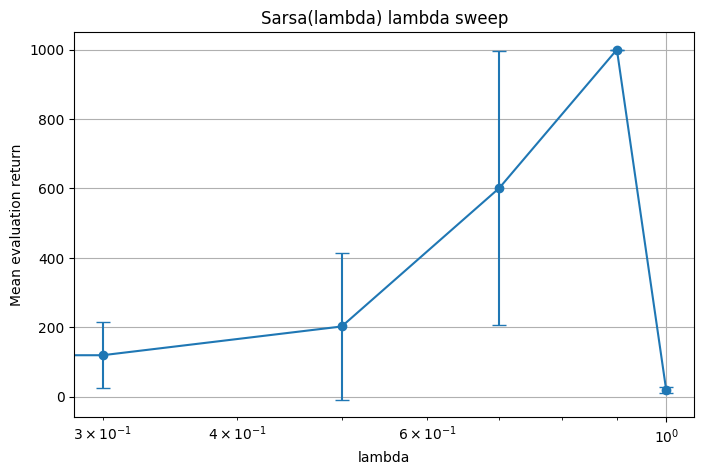

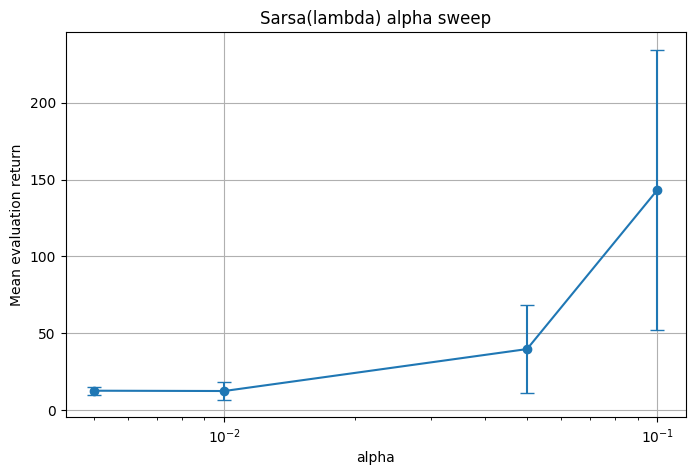

In [74]:
plot_sweep(sarsa_lambda_results, "lambda", "Sarsa(lambda) lambda sweep")
plot_sweep(sarsa_alpha_results, "alpha", "Sarsa(lambda) alpha sweep")

### 6.2 Sarsa($\lambda$): effect of $\lambda$

The trace parameter $\lambda$ has a strong and non-linear effect on performance.

The results show a clear pattern:

- Low values of $\lambda$ (e.g., 0.3) lead to poor performance
- Intermediate values (0.5-0.7) achieve optimal performance
- A high value ($\lambda \approx 0.9$) achieves near-optimal performance
- At $\lambda = 1.0$, performance collapses again

This indicates that the best performance is achieved with a large but not maximal trace parameter.

### Interpretation

Low values of $\lambda$ correspond to short eligibility traces, similar to one-step Sarsa. These updates propagate reward information slowly and fail to capture long-term dependencies in the environment.

Increasing $\lambda$ allows reward information to be propagated across longer sequences of states, significantly improving performance. This is particularly important in this environment, where survival depends on sequences of coordinated actions.

However, at $\lambda = 1.0$, the method becomes closer to Monte Carlo updates, which have higher variance. Combined with a fixed learning rate, this leads to unstable learning and poor performance.

### Conclusion

These results show that Sarsa($\lambda$) performs best with a high but not maximal value of $\lambda$, highlighting the importance of balancing bias and variance in temporal-difference learning.

### 6.3 Sarsa($\lambda$): effect of the learning rate $\alpha$

The learning rate $\alpha$ has a strong impact on performance.

The results show a clear pattern:

- Very small values of $\alpha$ lead to poor performance due to slow learning
- Larger values (e.g., 0.1) achieve near-optimal performance

This demonstrates that Sarsa($\lambda$) is highly sensitive to the learning rate. A well-chosen $\alpha$ is essential for achieving strong performance.

----------------------------------------

## 7. Generalization to a modified environment

To evaluate the robustness of the learned policies, we test both agents on a modified version of the environment.

The agents are trained on the default environment and then evaluated on a new environment with different dynamics. This allows us to assess how well the learned policies generalize beyond the training setting.

In [77]:
env_generalization = gym.make(
    "TextFlappyBird-v0",
    pipe_gap=2,
)



In [82]:
mc_gen_eval = mc_agent.evaluate(
    env_generalization,
    n_episodes=100,
    max_steps=1000,
    seed=5000
)

sarsa_gen_eval = sarsa_agent.evaluate(
    env_generalization,
    n_episodes=100,
    max_steps=1000,
    seed=6000
)

print("Monte Carlo (generalization):")
print(f"  Mean return: {mc_gen_eval['mean_return']:.2f} ± {mc_gen_eval['std_return']:.2f}")

print("\nSarsa(lambda) (generalization):")
print(f"  Mean return: {sarsa_gen_eval['mean_return']:.2f} ± {sarsa_gen_eval['std_return']:.2f}")

Monte Carlo (generalization):
  Mean return: 85.62 ± 83.11

Sarsa(lambda) (generalization):
  Mean return: 40.90 ± 28.68


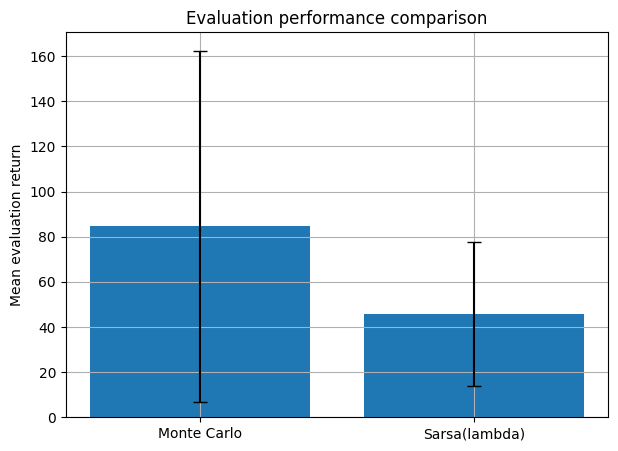

In [79]:
plot_eval_comparison(mc_gen_eval, sarsa_gen_eval)

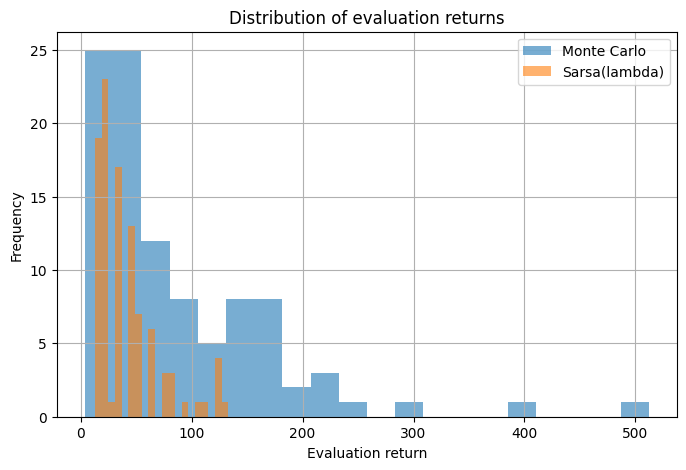

In [83]:
plot_return_distributions(mc_gen_eval, sarsa_gen_eval)

### Generalization performance

Both agents were evaluated on a modified version of the environment that differs from the training setup. I decreased the pipe gap from 4 to 2, making the environment more challenging.

Both agents fail to achieve the same level of performance as in the original environment, which is expected since they were trained specifically for the original dynamics.


Monte Carlo (generalization, pipe_gap=5):
  Mean return: 1000.00 ± 0.00

Sarsa(lambda) (generalization, pipe_gap=5):
  Mean return: 1000.00 ± 0.00


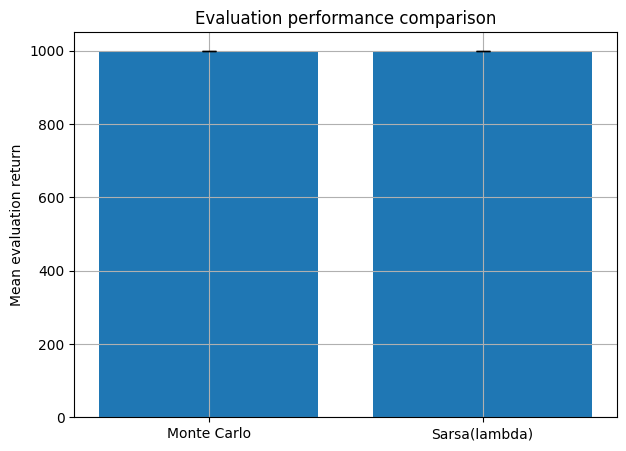

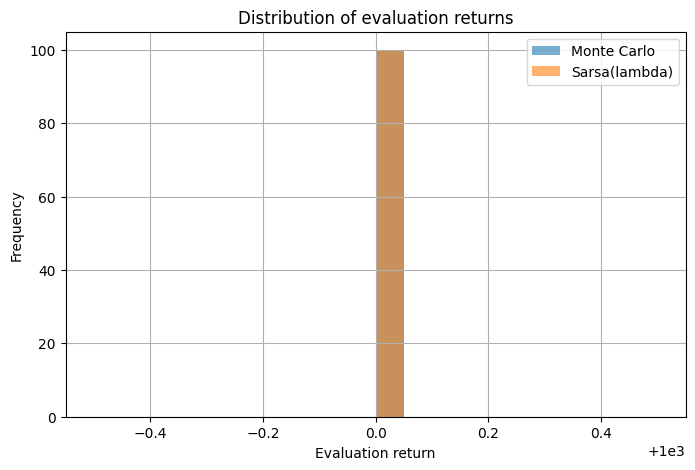

In [84]:
env_generalization = gym.make(
    "TextFlappyBird-v0",
    pipe_gap=5,
)

mc_gen_eval = mc_agent.evaluate(
    env_generalization,
    n_episodes=100,
    max_steps=1000,
    seed=7000
)
sarsa_gen_eval = sarsa_agent.evaluate(
    env_generalization,
    n_episodes=100,
    max_steps=1000,
    seed=8000
)
print("Monte Carlo (generalization, pipe_gap=5):")
print(f"  Mean return: {mc_gen_eval['mean_return']:.2f} ± {mc_gen_eval['std_return']:.2f}")
print("\nSarsa(lambda) (generalization, pipe_gap=5):")
print(f"  Mean return: {sarsa_gen_eval['mean_return']:.2f} ± {sarsa_gen_eval['std_return']:.2f}")
plot_eval_comparison(mc_gen_eval, sarsa_gen_eval)
plot_return_distributions(mc_gen_eval, sarsa_gen_eval)


For an easier environment (e.g., pipe gap of 5), both agents achieve perfect or near-perfect performance, indicating that they can generalize to simpler variations of the task. However, when the environment is made more difficult (e.g., pipe gap of 2), both agents struggle immensely.